# Notebook 04: Pore-Pressure Sensitivity Analysis

## Purpose

This notebook investigates how increasing pore-water pressure reduces the effective normal stress and shear resistance of the DEM particle assembly.

The accepted results from Notebook 03 are used as the reference drained direct-shear condition.

## Background

According to the effective-stress principle:

$
\sigma'_v = \sigma_v - u
$

where:

* (\sigma'_v) is the effective vertical stress,
* (\sigma_v) is the total vertical stress,
* (u) is the pore-water pressure.

As pore pressure increases, the effective stress carried by the particle skeleton decreases. This reduces the frictional shear resistance of the material.

The shear resistance is evaluated using:

$
\tau_f = c' + \sigma'_v \tan(\phi')
$

where:

* $\tau_f$ is the available shear resistance,
* $c'$ is the effective cohesion,
* $\phi'$ is the effective friction angle.

For the current granular DEM material, the effective cohesion will initially be assumed to be zero.

## Workflow

This notebook will:

1. Load and validate the accepted Notebook 03 shear results and restart file.
2. Extract the reference total vertical stress and shear resistance.
3. Define a range of pore-pressure conditions.
4. Calculate effective vertical stress for each pore-pressure condition.
5. Estimate the corresponding reduction in peak and residual shear resistance.
6. Calculate pore-pressure ratio and effective-stress ratio.
7. Identify conditions approaching loss of shear resistance.
8. Produce diagnostic plots and save the sensitivity results.

## Input Files

* `results/shear/dem_shear_results.npz`
* `results/restart/sheared_particle_packing.npz`

## Planned Output

The pore-pressure sensitivity results will be saved in:

* `results/pore_pressure/pore_pressure_sensitivity_results.npz`


In [1]:
import numpy as np
from pathlib import Path


# ============================================================
# NOTEBOOK 04: PORE-PRESSURE SENSITIVITY
# CELL 2: LOAD AND VALIDATE NOTEBOOK 03 FILES
# ============================================================


# ------------------------------------------------------------
# 1. Define required input-file paths
# ------------------------------------------------------------

shear_results_path = Path(
    "results/shear/dem_shear_results.npz"
)

sheared_restart_path = Path(
    "results/restart/sheared_particle_packing.npz"
)


# ------------------------------------------------------------
# 2. Confirm that both files exist
# ------------------------------------------------------------

required_files = [
    shear_results_path,
    sheared_restart_path,
]

missing_files = [
    file_path
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    missing_text = "\n".join(
        f"  - {file_path}"
        for file_path in missing_files
    )

    raise FileNotFoundError(
        "Required Notebook 03 files were not found:\n"
        f"{missing_text}\n\n"
        "Run this notebook from the main project folder."
    )


# ------------------------------------------------------------
# 3. Load the shear-history results
# ------------------------------------------------------------

with np.load(
    shear_results_path,
    allow_pickle=False,
) as loaded_file:

    shear_results = {
        key: loaded_file[key].copy()
        for key in loaded_file.files
    }


# ------------------------------------------------------------
# 4. Load the sheared particle restart
# ------------------------------------------------------------

with np.load(
    sheared_restart_path,
    allow_pickle=False,
) as loaded_file:

    sheared_restart = {
        key: loaded_file[key].copy()
        for key in loaded_file.files
    }


# ------------------------------------------------------------
# 5. Print all stored variables
# ------------------------------------------------------------

print("NOTEBOOK 03 FILES LOADED")
print("=" * 75)

print("\nShear-results file")
print("-" * 75)
print(f"Path: {shear_results_path.resolve()}")

for key in sorted(shear_results.keys()):
    value = np.asarray(shear_results[key])

    if value.ndim == 0:
        print(
            f"{key:<40} "
            f"scalar = {value.item()}"
        )
    else:
        print(
            f"{key:<40} "
            f"shape = {value.shape}, "
            f"dtype = {value.dtype}"
        )


print("\nSheared-packing restart file")
print("-" * 75)
print(f"Path: {sheared_restart_path.resolve()}")

for key in sorted(sheared_restart.keys()):
    value = np.asarray(sheared_restart[key])

    if value.ndim == 0:
        print(
            f"{key:<40} "
            f"scalar = {value.item()}"
        )
    else:
        print(
            f"{key:<40} "
            f"shape = {value.shape}, "
            f"dtype = {value.dtype}"
        )


# ------------------------------------------------------------
# 6. Identify essential restart variables
# ------------------------------------------------------------

def find_key(data, possible_keys, variable_name):
    for key in possible_keys:
        if key in data:
            return key

    raise KeyError(
        f"Could not identify {variable_name}.\n"
        f"Expected one of: {possible_keys}\n"
        f"Available keys: {sorted(data.keys())}"
    )


position_key = find_key(
    sheared_restart,
    [
        "positions",
        "particle_positions",
    ],
    "particle positions",
)

radius_key = find_key(
    sheared_restart,
    [
        "radii",
        "particle_radii",
    ],
    "particle radii",
)

velocity_key = find_key(
    sheared_restart,
    [
        "velocities",
        "particle_velocities",
    ],
    "particle velocities",
)


particle_positions = np.asarray(
    sheared_restart[position_key],
    dtype=float,
)

particle_radii = np.asarray(
    sheared_restart[radius_key],
    dtype=float,
)

particle_velocities = np.asarray(
    sheared_restart[velocity_key],
    dtype=float,
)


# ------------------------------------------------------------
# 7. Validate particle arrays
# ------------------------------------------------------------

if particle_positions.ndim != 2:
    raise ValueError(
        "Particle positions must be a two-dimensional array."
    )

if particle_positions.shape[1] != 2:
    raise ValueError(
        "Particle positions must contain x and y coordinates."
    )

number_of_particles = particle_positions.shape[0]

if particle_radii.shape != (number_of_particles,):
    raise ValueError(
        "Particle-radii array has an unexpected shape.\n"
        f"Expected: ({number_of_particles},)\n"
        f"Loaded:   {particle_radii.shape}"
    )

if particle_velocities.shape != (
    number_of_particles,
    2,
):
    raise ValueError(
        "Particle-velocity array has an unexpected shape.\n"
        f"Expected: ({number_of_particles}, 2)\n"
        f"Loaded:   {particle_velocities.shape}"
    )


# ------------------------------------------------------------
# 8. Check numerical validity
# ------------------------------------------------------------

validation_arrays = {
    "particle positions": particle_positions,
    "particle radii": particle_radii,
    "particle velocities": particle_velocities,
}

for array_name, array_values in validation_arrays.items():

    if not np.all(np.isfinite(array_values)):
        raise ValueError(
            f"{array_name} contain NaN or infinite values."
        )


if np.any(particle_radii <= 0.0):
    raise ValueError(
        "All particle radii must be greater than zero."
    )


# ------------------------------------------------------------
# 9. Confirm the expected particle count
# ------------------------------------------------------------

expected_number_of_particles = 120

if number_of_particles != expected_number_of_particles:
    raise ValueError(
        "Unexpected number of particles.\n"
        f"Expected: {expected_number_of_particles}\n"
        f"Loaded:   {number_of_particles}"
    )


# ------------------------------------------------------------
# 10. Identify useful Notebook 03 history variables
# ------------------------------------------------------------

def find_optional_key(data, possible_keys):
    for key in possible_keys:
        if key in data:
            return key

    return None


shear_strain_key = find_optional_key(
    shear_results,
    [
        "shear_strain_history",
        "shear_strain",
    ],
)

shear_stress_key = find_optional_key(
    shear_results,
    [
        "shear_stress_history",
        "shear_stress",
    ],
)

vertical_stress_key = find_optional_key(
    shear_results,
    [
        "vertical_stress_history",
        "filtered_vertical_stress_history",
        "vertical_stress",
    ],
)


# ------------------------------------------------------------
# 11. Print validation summary
# ------------------------------------------------------------

particle_speeds = np.linalg.norm(
    particle_velocities,
    axis=1,
)

print("\nVALIDATION SUMMARY")
print("=" * 75)
print(f"Number of particles           : {number_of_particles}")
print(f"Particle-position shape       : {particle_positions.shape}")
print(f"Particle-radius shape         : {particle_radii.shape}")
print(f"Particle-velocity shape       : {particle_velocities.shape}")
print(f"Minimum particle radius       : {particle_radii.min():.6e} m")
print(f"Maximum particle radius       : {particle_radii.max():.6e} m")
print(f"Maximum particle speed        : {particle_speeds.max():.6e} m/s")
print(f"Shear-strain history key      : {shear_strain_key}")
print(f"Shear-stress history key      : {shear_stress_key}")
print(f"Vertical-stress history key   : {vertical_stress_key}")

print("\nCELL 2 PASSED")
print(
    "The accepted Notebook 03 shear results and restart "
    "are loaded and valid."
)

NOTEBOOK 03 FILES LOADED

Shear-results file
---------------------------------------------------------------------------
Path: C:\Users\duaas\dike_fem_dem_project\results\shear\dem_shear_results.npz
coordination_number                      shape = (3417,), dtype = float64
filtered_vertical_stress                 shape = (3417,), dtype = float64
final_coordination_number                scalar = 2.966666666666667
final_kinetic_energy                     scalar = 1.572189665720285e-08
final_relative_overlap                   scalar = 0.009348497566139471
final_shear_strain                       scalar = 0.08002048818186447
final_shear_stress                       scalar = 7734.171008123213
final_stress_ratio                       scalar = 0.24568893995454893
final_vertical_stress                    scalar = 31479.524514021636
integrated_stress_error                  shape = (3417,), dtype = float64
kinetic_energy                           shape = (3417,), dtype = float64
maximum_overlap  

In [2]:
# ============================================================
# NOTEBOOK 04: PORE-PRESSURE SENSITIVITY
# CELL 4: EXTRACT AND VALIDATE THE REFERENCE SHEAR STATE
# ============================================================


# ------------------------------------------------------------
# 1. Extract required scalar values from Notebook 03
# ------------------------------------------------------------

required_scalar_keys = [
    "shear_target_vertical_stress",
    "final_vertical_stress",
    "peak_shear_stress",
    "final_shear_stress",
    "peak_shear_strain",
    "final_shear_strain",
    "peak_stress_ratio",
    "final_stress_ratio",
    "final_coordination_number",
    "final_kinetic_energy",
    "run_accepted",
]

missing_scalar_keys = [
    key
    for key in required_scalar_keys
    if key not in shear_results
]

if missing_scalar_keys:
    raise KeyError(
        "The following required scalar values are missing from "
        "the Notebook 03 results file:\n"
        + "\n".join(f"  - {key}" for key in missing_scalar_keys)
    )


reference_total_vertical_stress = float(
    shear_results["shear_target_vertical_stress"]
)

reference_final_vertical_stress = float(
    shear_results["final_vertical_stress"]
)

reference_peak_shear_stress = float(
    shear_results["peak_shear_stress"]
)

reference_final_shear_stress = float(
    shear_results["final_shear_stress"]
)

reference_peak_shear_strain = float(
    shear_results["peak_shear_strain"]
)

reference_final_shear_strain = float(
    shear_results["final_shear_strain"]
)

reference_peak_stress_ratio = float(
    shear_results["peak_stress_ratio"]
)

reference_final_stress_ratio = float(
    shear_results["final_stress_ratio"]
)

reference_coordination_number = float(
    shear_results["final_coordination_number"]
)

reference_kinetic_energy = float(
    shear_results["final_kinetic_energy"]
)

notebook_03_run_accepted = bool(
    shear_results["run_accepted"]
)


# ------------------------------------------------------------
# 2. Extract complete shear histories
# ------------------------------------------------------------

reference_shear_strain_history = np.asarray(
    shear_results["shear_strain"],
    dtype=float,
)

reference_shear_stress_history = np.asarray(
    shear_results["shear_stress"],
    dtype=float,
)

reference_vertical_stress_history = np.asarray(
    shear_results["vertical_stress"],
    dtype=float,
)

reference_filtered_vertical_stress_history = np.asarray(
    shear_results["filtered_vertical_stress"],
    dtype=float,
)

reference_stress_ratio_history = np.asarray(
    shear_results["stress_ratio"],
    dtype=float,
)

reference_step_history = np.asarray(
    shear_results["step"],
    dtype=int,
)

reference_time_history = np.asarray(
    shear_results["time"],
    dtype=float,
)


# ------------------------------------------------------------
# 3. Validate history lengths
# ------------------------------------------------------------

history_arrays = {
    "shear strain": reference_shear_strain_history,
    "shear stress": reference_shear_stress_history,
    "vertical stress": reference_vertical_stress_history,
    "filtered vertical stress":
        reference_filtered_vertical_stress_history,
    "stress ratio": reference_stress_ratio_history,
    "step": reference_step_history,
    "time": reference_time_history,
}

history_lengths = {
    name: array.shape[0]
    for name, array in history_arrays.items()
}

unique_history_lengths = set(history_lengths.values())

if len(unique_history_lengths) != 1:
    raise ValueError(
        "Notebook 03 history arrays do not have equal lengths:\n"
        + "\n".join(
            f"  {name:<28}: {length}"
            for name, length in history_lengths.items()
        )
    )

number_of_saved_states = unique_history_lengths.pop()


# ------------------------------------------------------------
# 4. Check numerical validity
# ------------------------------------------------------------

for history_name, history_values in history_arrays.items():

    if history_values.ndim != 1:
        raise ValueError(
            f"The {history_name} history must be one-dimensional, "
            f"but its shape is {history_values.shape}."
        )

    if not np.all(np.isfinite(history_values)):
        raise ValueError(
            f"The {history_name} history contains NaN or infinite values."
        )


scalar_values_to_check = {
    "reference total vertical stress":
        reference_total_vertical_stress,
    "reference final vertical stress":
        reference_final_vertical_stress,
    "reference peak shear stress":
        reference_peak_shear_stress,
    "reference final shear stress":
        reference_final_shear_stress,
    "reference peak shear strain":
        reference_peak_shear_strain,
    "reference final shear strain":
        reference_final_shear_strain,
    "reference peak stress ratio":
        reference_peak_stress_ratio,
    "reference final stress ratio":
        reference_final_stress_ratio,
    "reference coordination number":
        reference_coordination_number,
    "reference kinetic energy":
        reference_kinetic_energy,
}

for value_name, value in scalar_values_to_check.items():

    if not np.isfinite(value):
        raise ValueError(
            f"{value_name} is not finite."
        )


# ------------------------------------------------------------
# 5. Validate physical consistency
# ------------------------------------------------------------

if not notebook_03_run_accepted:
    raise ValueError(
        "Notebook 03 was not marked as accepted."
    )

if reference_total_vertical_stress <= 0.0:
    raise ValueError(
        "The reference total vertical stress must be positive."
    )

if reference_peak_shear_stress <= 0.0:
    raise ValueError(
        "The reference peak shear stress must be positive."
    )

if reference_final_shear_stress <= 0.0:
    raise ValueError(
        "The reference final shear stress must be positive."
    )

if reference_peak_shear_stress < reference_final_shear_stress:
    raise ValueError(
        "The peak shear stress is unexpectedly smaller than "
        "the final shear stress."
    )

if reference_peak_shear_strain >= reference_final_shear_strain:
    raise ValueError(
        "The peak shear strain must occur before the final shear strain."
    )

if not np.all(np.diff(reference_shear_strain_history) >= -1.0e-12):
    raise ValueError(
        "The shear-strain history is not monotonically increasing."
    )


# ------------------------------------------------------------
# 6. Recalculate key stress ratios for consistency
# ------------------------------------------------------------

recalculated_peak_stress_ratio = (
    reference_peak_shear_stress
    / reference_total_vertical_stress
)

recalculated_final_stress_ratio = (
    reference_final_shear_stress
    / reference_final_vertical_stress
)

peak_ratio_difference = abs(
    recalculated_peak_stress_ratio
    - reference_peak_stress_ratio
)

final_ratio_difference = abs(
    recalculated_final_stress_ratio
    - reference_final_stress_ratio
)


# ------------------------------------------------------------
# 7. Calculate reference friction-angle estimates
# ------------------------------------------------------------

reference_peak_friction_angle_deg = np.degrees(
    np.arctan(reference_peak_stress_ratio)
)

reference_final_friction_angle_deg = np.degrees(
    np.arctan(reference_final_stress_ratio)
)


# ------------------------------------------------------------
# 8. Print the reference-state summary
# ------------------------------------------------------------

print("REFERENCE SHEAR STATE")
print("=" * 75)

print(f"Notebook 03 accepted              : {notebook_03_run_accepted}")
print(f"Number of saved states            : {number_of_saved_states}")

print("\nReference stresses")
print("-" * 75)
print(
    f"Target total vertical stress      : "
    f"{reference_total_vertical_stress / 1000.0:.4f} kPa"
)
print(
    f"Final measured vertical stress    : "
    f"{reference_final_vertical_stress / 1000.0:.4f} kPa"
)
print(
    f"Peak shear stress                 : "
    f"{reference_peak_shear_stress / 1000.0:.4f} kPa"
)
print(
    f"Final shear stress                : "
    f"{reference_final_shear_stress / 1000.0:.4f} kPa"
)

print("\nReference strains")
print("-" * 75)
print(
    f"Shear strain at peak stress       : "
    f"{reference_peak_shear_strain:.6f}"
)
print(
    f"Final shear strain                : "
    f"{reference_final_shear_strain:.6f}"
)

print("\nReference stress ratios")
print("-" * 75)
print(
    f"Stored peak stress ratio          : "
    f"{reference_peak_stress_ratio:.6f}"
)
print(
    f"Recalculated peak stress ratio    : "
    f"{recalculated_peak_stress_ratio:.6f}"
)
print(
    f"Peak ratio difference             : "
    f"{peak_ratio_difference:.6e}"
)
print(
    f"Stored final stress ratio         : "
    f"{reference_final_stress_ratio:.6f}"
)
print(
    f"Recalculated final stress ratio   : "
    f"{recalculated_final_stress_ratio:.6f}"
)
print(
    f"Final ratio difference            : "
    f"{final_ratio_difference:.6e}"
)

print("\nEquivalent friction-angle estimates")
print("-" * 75)
print(
    f"Peak friction angle estimate      : "
    f"{reference_peak_friction_angle_deg:.3f} degrees"
)
print(
    f"Final friction angle estimate     : "
    f"{reference_final_friction_angle_deg:.3f} degrees"
)

print("\nAdditional state information")
print("-" * 75)
print(
    f"Final coordination number         : "
    f"{reference_coordination_number:.3f}"
)
print(
    f"Final kinetic energy              : "
    f"{reference_kinetic_energy:.6e} J"
)

print("\nCELL 4 PASSED")
print(
    "The accepted Notebook 03 reference state has been "
    "extracted and validated."
)

REFERENCE SHEAR STATE
Notebook 03 accepted              : True
Number of saved states            : 3417

Reference stresses
---------------------------------------------------------------------------
Target total vertical stress      : 33.4271 kPa
Final measured vertical stress    : 31.4795 kPa
Peak shear stress                 : 13.9385 kPa
Final shear stress                : 7.7342 kPa

Reference strains
---------------------------------------------------------------------------
Shear strain at peak stress       : 0.033053
Final shear strain                : 0.080020

Reference stress ratios
---------------------------------------------------------------------------
Stored peak stress ratio          : 0.415233
Recalculated peak stress ratio    : 0.416982
Peak ratio difference             : 1.749340e-03
Stored final stress ratio         : 0.245689
Recalculated final stress ratio   : 0.245689
Final ratio difference            : 0.000000e+00

Equivalent friction-angle estimates
--------

## Pore-Pressure Loading Cases

The accepted Notebook 03 shear test represents the reference condition with zero excess pore-water pressure.

For the sensitivity analysis, pore pressure will be expressed using the pore-pressure ratio:

$$
r_u = \frac{u}{\sigma_v}
$$

where:

* $r_u$ is the pore-pressure ratio,
* $u$ is the pore-water pressure,
* $\sigma_v$ is the total vertical stress.

The corresponding effective vertical stress is:

$$
\sigma'_v = \sigma_v(1-r_u)
$$

The analysis will use pore-pressure ratios from:

$$
r_u = 0.0 \quad \text{to} \quad 0.95
$$

A value of $r_u = 0$ represents the original drained reference state.

As $r_u$ approaches $1.0$, the effective stress approaches zero and the frictional shear resistance of the particle skeleton becomes very small.

Assuming zero effective cohesion and a constant friction angle, the available shear resistance scales directly with effective stress:

$$
\tau(u) = \tau_0(1-r_u)
$$

This relationship will be applied separately to:

* peak shear resistance,
* final or residual shear resistance.

The next code cell will define the pore-pressure cases and calculate the corresponding effective stresses.


In [3]:
# ============================================================
# NOTEBOOK 04: PORE-PRESSURE SENSITIVITY
# CELL 5: DEFINE PORE-PRESSURE CASES
# ============================================================


# ------------------------------------------------------------
# 1. Define pore-pressure ratios
# ------------------------------------------------------------

pore_pressure_ratio = np.array(
    [
        0.00,
        0.10,
        0.20,
        0.30,
        0.40,
        0.50,
        0.60,
        0.70,
        0.80,
        0.90,
        0.95,
    ],
    dtype=float,
)


# ------------------------------------------------------------
# 2. Validate pore-pressure ratios
# ------------------------------------------------------------

if pore_pressure_ratio.ndim != 1:
    raise ValueError(
        "The pore-pressure-ratio array must be one-dimensional."
    )

if not np.all(np.isfinite(pore_pressure_ratio)):
    raise ValueError(
        "The pore-pressure-ratio array contains NaN or infinite values."
    )

if np.any(pore_pressure_ratio < 0.0):
    raise ValueError(
        "Pore-pressure ratios cannot be negative."
    )

if np.any(pore_pressure_ratio >= 1.0):
    raise ValueError(
        "All pore-pressure ratios must remain below 1.0."
    )

if not np.all(np.diff(pore_pressure_ratio) > 0.0):
    raise ValueError(
        "Pore-pressure ratios must be strictly increasing."
    )


# ------------------------------------------------------------
# 3. Calculate pore pressure and effective vertical stress
# ------------------------------------------------------------

total_vertical_stress = reference_total_vertical_stress

pore_pressure = (
    pore_pressure_ratio
    * total_vertical_stress
)

effective_vertical_stress = (
    total_vertical_stress
    - pore_pressure
)

effective_stress_ratio = (
    effective_vertical_stress
    / total_vertical_stress
)


# ------------------------------------------------------------
# 4. Calculate normalized stress reduction
# ------------------------------------------------------------

stress_reduction_fraction = (
    1.0
    - effective_stress_ratio
)

stress_reduction_percent = (
    stress_reduction_fraction
    * 100.0
)


# ------------------------------------------------------------
# 5. Validate calculated values
# ------------------------------------------------------------

calculated_arrays = {
    "pore pressure": pore_pressure,
    "effective vertical stress": effective_vertical_stress,
    "effective stress ratio": effective_stress_ratio,
    "stress reduction fraction": stress_reduction_fraction,
    "stress reduction percent": stress_reduction_percent,
}

for array_name, array_values in calculated_arrays.items():

    if not np.all(np.isfinite(array_values)):
        raise ValueError(
            f"The calculated {array_name} contains "
            "NaN or infinite values."
        )


if np.any(effective_vertical_stress <= 0.0):
    raise ValueError(
        "All effective vertical stresses must remain positive."
    )


if not np.allclose(
    effective_stress_ratio,
    1.0 - pore_pressure_ratio,
    rtol=1.0e-12,
    atol=1.0e-12,
):
    raise ValueError(
        "The effective-stress-ratio calculation is inconsistent."
    )


# ------------------------------------------------------------
# 6. Print pore-pressure sensitivity table
# ------------------------------------------------------------

print("PORE-PRESSURE CASES")
print("=" * 86)

print(
    f"{'Case':>4} "
    f"{'r_u':>8} "
    f"{'u (kPa)':>12} "
    f"{'sigma_v (kPa)':>16} "
    f"{'sigma_eff (kPa)':>18} "
    f"{'Reduction (%)':>16}"
)

print("-" * 86)

for case_index in range(len(pore_pressure_ratio)):

    print(
        f"{case_index:>4d} "
        f"{pore_pressure_ratio[case_index]:>8.2f} "
        f"{pore_pressure[case_index] / 1000.0:>12.4f} "
        f"{total_vertical_stress / 1000.0:>16.4f} "
        f"{effective_vertical_stress[case_index] / 1000.0:>18.4f} "
        f"{stress_reduction_percent[case_index]:>16.1f}"
    )


# ------------------------------------------------------------
# 7. Print summary
# ------------------------------------------------------------

print("\nPORE-PRESSURE RANGE SUMMARY")
print("=" * 86)
print(
    f"Total vertical stress             : "
    f"{total_vertical_stress / 1000.0:.4f} kPa"
)
print(
    f"Minimum pore-pressure ratio       : "
    f"{pore_pressure_ratio.min():.2f}"
)
print(
    f"Maximum pore-pressure ratio       : "
    f"{pore_pressure_ratio.max():.2f}"
)
print(
    f"Maximum pore pressure             : "
    f"{pore_pressure.max() / 1000.0:.4f} kPa"
)
print(
    f"Minimum effective vertical stress : "
    f"{effective_vertical_stress.min() / 1000.0:.4f} kPa"
)

print("\nCELL 5 PASSED")
print(
    "The pore-pressure cases and corresponding effective "
    "vertical stresses have been calculated."
)

PORE-PRESSURE CASES
Case      r_u      u (kPa)    sigma_v (kPa)    sigma_eff (kPa)    Reduction (%)
--------------------------------------------------------------------------------------
   0     0.00       0.0000          33.4271            33.4271              0.0
   1     0.10       3.3427          33.4271            30.0844             10.0
   2     0.20       6.6854          33.4271            26.7417             20.0
   3     0.30      10.0281          33.4271            23.3990             30.0
   4     0.40      13.3709          33.4271            20.0563             40.0
   5     0.50      16.7136          33.4271            16.7136             50.0
   6     0.60      20.0563          33.4271            13.3709             60.0
   7     0.70      23.3990          33.4271            10.0281             70.0
   8     0.80      26.7417          33.4271             6.6854             80.0
   9     0.90      30.0844          33.4271             3.3427             90.0
  10     0.95

In [5]:
# ============================================================
# NOTEBOOK 04: PORE-PRESSURE SENSITIVITY
# CELL 6: CALCULATE SHEAR-RESISTANCE REDUCTION
# ============================================================


# ------------------------------------------------------------
# 1. Define reference strength parameters
# ------------------------------------------------------------

effective_cohesion = 0.0

peak_friction_coefficient = (
    reference_peak_shear_stress
    / reference_total_vertical_stress
)

final_friction_coefficient = (
    reference_final_shear_stress
    / reference_final_vertical_stress
)

peak_friction_angle_deg = np.degrees(
    np.arctan(peak_friction_coefficient)
)

final_friction_angle_deg = np.degrees(
    np.arctan(final_friction_coefficient)
)


# ------------------------------------------------------------
# 2. Scale accepted shear strengths with effective stress
# ------------------------------------------------------------

normalized_effective_stress = (
    1.0 - pore_pressure_ratio
)

peak_shear_resistance = (
    reference_peak_shear_stress
    * normalized_effective_stress
)

final_shear_resistance = (
    reference_final_shear_stress
    * normalized_effective_stress
)


# ------------------------------------------------------------
# 3. Calculate normalized resistance and strength loss
# ------------------------------------------------------------

normalized_peak_resistance = (
    peak_shear_resistance
    / reference_peak_shear_stress
)

normalized_final_resistance = (
    final_shear_resistance
    / reference_final_shear_stress
)

peak_resistance_reduction_percent = (
    1.0 - normalized_peak_resistance
) * 100.0

final_resistance_reduction_percent = (
    1.0 - normalized_final_resistance
) * 100.0


# ------------------------------------------------------------
# 4. Validate calculated arrays
# ------------------------------------------------------------

resistance_arrays = {
    "peak shear resistance": peak_shear_resistance,
    "final shear resistance": final_shear_resistance,
    "normalized peak resistance": normalized_peak_resistance,
    "normalized final resistance": normalized_final_resistance,
    "peak resistance reduction":
        peak_resistance_reduction_percent,
    "final resistance reduction":
        final_resistance_reduction_percent,
}

for array_name, array_values in resistance_arrays.items():

    if not np.all(np.isfinite(array_values)):
        raise ValueError(
            f"The calculated {array_name} contains "
            "NaN or infinite values."
        )


if np.any(peak_shear_resistance < 0.0):
    raise ValueError(
        "Peak shear resistance cannot be negative."
    )

if np.any(final_shear_resistance < 0.0):
    raise ValueError(
        "Final shear resistance cannot be negative."
    )

if np.any(
    peak_shear_resistance
    < final_shear_resistance
):
    raise ValueError(
        "Peak shear resistance must not be smaller than "
        "final shear resistance."
    )


# ------------------------------------------------------------
# 5. Confirm exact recovery of the reference state
# ------------------------------------------------------------

if not np.isclose(
    peak_shear_resistance[0],
    reference_peak_shear_stress,
    rtol=1.0e-12,
    atol=1.0e-12,
):
    raise ValueError(
        "The zero-pore-pressure peak resistance does not "
        "match the accepted Notebook 03 peak shear stress."
    )

if not np.isclose(
    final_shear_resistance[0],
    reference_final_shear_stress,
    rtol=1.0e-12,
    atol=1.0e-12,
):
    raise ValueError(
        "The zero-pore-pressure final resistance does not "
        "match the accepted Notebook 03 final shear stress."
    )

if not np.allclose(
    normalized_peak_resistance,
    normalized_effective_stress,
    rtol=1.0e-12,
    atol=1.0e-12,
):
    raise ValueError(
        "Peak resistance does not scale consistently "
        "with effective stress."
    )

if not np.allclose(
    normalized_final_resistance,
    normalized_effective_stress,
    rtol=1.0e-12,
    atol=1.0e-12,
):
    raise ValueError(
        "Final resistance does not scale consistently "
        "with effective stress."
    )


# ------------------------------------------------------------
# 6. Identify sensitivity thresholds
# ------------------------------------------------------------

peak_below_half_reference = (
    normalized_peak_resistance
    <= 0.50 + 1.0e-12
)

peak_below_quarter_reference = (
    normalized_peak_resistance
    <= 0.25 + 1.0e-12
)

final_below_half_reference = (
    normalized_final_resistance
    <= 0.50 + 1.0e-12
)


def first_matching_case(condition_array):
    matching_indices = np.flatnonzero(condition_array)

    if matching_indices.size == 0:
        return None

    return int(matching_indices[0])


peak_half_case = first_matching_case(
    peak_below_half_reference
)

peak_quarter_case = first_matching_case(
    peak_below_quarter_reference
)

final_half_case = first_matching_case(
    final_below_half_reference
)


# ------------------------------------------------------------
# 7. Print shear-resistance table
# ------------------------------------------------------------

print("PORE-PRESSURE SHEAR-RESISTANCE SENSITIVITY")
print("=" * 104)

print(
    f"{'Case':>4} "
    f"{'r_u':>7} "
    f"{'sigma_eff':>12} "
    f"{'Peak tau':>12} "
    f"{'Final tau':>12} "
    f"{'Peak norm.':>12} "
    f"{'Final norm.':>12} "
    f"{'Peak loss':>12}"
)

print(
    f"{'':>4} "
    f"{'':>7} "
    f"{'(kPa)':>12} "
    f"{'(kPa)':>12} "
    f"{'(kPa)':>12} "
    f"{'(-)':>12} "
    f"{'(-)':>12} "
    f"{'(%)':>12}"
)

print("-" * 104)

for case_index in range(len(pore_pressure_ratio)):

    print(
        f"{case_index:>4d} "
        f"{pore_pressure_ratio[case_index]:>7.2f} "
        f"{effective_vertical_stress[case_index] / 1000.0:>12.4f} "
        f"{peak_shear_resistance[case_index] / 1000.0:>12.4f} "
        f"{final_shear_resistance[case_index] / 1000.0:>12.4f} "
        f"{normalized_peak_resistance[case_index]:>12.4f} "
        f"{normalized_final_resistance[case_index]:>12.4f} "
        f"{peak_resistance_reduction_percent[case_index]:>12.1f}"
    )


# ------------------------------------------------------------
# 8. Print parameter and threshold summaries
# ------------------------------------------------------------

print("\nREFERENCE STRENGTH PARAMETERS")
print("=" * 104)
print(
    f"Effective cohesion                 : "
    f"{effective_cohesion / 1000.0:.4f} kPa"
)
print(
    f"Peak friction coefficient         : "
    f"{peak_friction_coefficient:.6f}"
)
print(
    f"Peak friction angle               : "
    f"{peak_friction_angle_deg:.3f} degrees"
)
print(
    f"Final friction coefficient        : "
    f"{final_friction_coefficient:.6f}"
)
print(
    f"Final friction angle              : "
    f"{final_friction_angle_deg:.3f} degrees"
)

print("\nREFERENCE-STATE CHECK")
print("=" * 104)
print(
    f"Accepted peak shear stress        : "
    f"{reference_peak_shear_stress / 1000.0:.4f} kPa"
)
print(
    f"Calculated peak at r_u = 0        : "
    f"{peak_shear_resistance[0] / 1000.0:.4f} kPa"
)
print(
    f"Accepted final shear stress       : "
    f"{reference_final_shear_stress / 1000.0:.4f} kPa"
)
print(
    f"Calculated final at r_u = 0       : "
    f"{final_shear_resistance[0] / 1000.0:.4f} kPa"
)

print("\nSENSITIVITY THRESHOLDS")
print("=" * 104)

if peak_half_case is not None:
    print(
        f"Peak resistance reaches 50% at    : "
        f"r_u = {pore_pressure_ratio[peak_half_case]:.2f}"
    )

if peak_quarter_case is not None:
    print(
        f"Peak resistance reaches 25% at    : "
        f"r_u = {pore_pressure_ratio[peak_quarter_case]:.2f}"
    )

if final_half_case is not None:
    print(
        f"Final resistance reaches 50% at   : "
        f"r_u = {pore_pressure_ratio[final_half_case]:.2f}"
    )


print("\nCELL 6 PASSED")
print(
    "Peak and final shear resistance recover the accepted "
    "Notebook 03 values at zero pore pressure and decrease "
    "consistently with effective stress."
)

PORE-PRESSURE SHEAR-RESISTANCE SENSITIVITY
Case     r_u    sigma_eff     Peak tau    Final tau   Peak norm.  Final norm.    Peak loss
                    (kPa)        (kPa)        (kPa)          (-)          (-)          (%)
--------------------------------------------------------------------------------------------------------
   0    0.00      33.4271      13.9385       7.7342       1.0000       1.0000          0.0
   1    0.10      30.0844      12.5447       6.9608       0.9000       0.9000         10.0
   2    0.20      26.7417      11.1508       6.1873       0.8000       0.8000         20.0
   3    0.30      23.3990       9.7570       5.4139       0.7000       0.7000         30.0
   4    0.40      20.0563       8.3631       4.6405       0.6000       0.6000         40.0
   5    0.50      16.7136       6.9693       3.8671       0.5000       0.5000         50.0
   6    0.60      13.3709       5.5754       3.0937       0.4000       0.4000         60.0
   7    0.70      10.0281       4

In [6]:
# ============================================================
# NOTEBOOK 04: PORE-PRESSURE SENSITIVITY
# CELL 7: GENERATE SCALED SHEAR STRESS-STRAIN CURVES
# ============================================================


# ------------------------------------------------------------
# 1. Create one shear-stress history for each pore-pressure case
# ------------------------------------------------------------

number_of_pore_pressure_cases = len(
    pore_pressure_ratio
)

number_of_shear_states = len(
    reference_shear_strain_history
)

scaled_shear_stress_histories = np.zeros(
    (
        number_of_pore_pressure_cases,
        number_of_shear_states,
    ),
    dtype=float,
)


for case_index, reduction_factor in enumerate(
    normalized_effective_stress
):

    scaled_shear_stress_histories[
        case_index,
        :
    ] = (
        reference_shear_stress_history
        * reduction_factor
    )


# ------------------------------------------------------------
# 2. Calculate stress-ratio histories
# ------------------------------------------------------------

scaled_stress_ratio_histories = np.zeros_like(
    scaled_shear_stress_histories
)

for case_index in range(
    number_of_pore_pressure_cases
):

    scaled_stress_ratio_histories[
        case_index,
        :
    ] = (
        scaled_shear_stress_histories[
            case_index,
            :
        ]
        / effective_vertical_stress[
            case_index
        ]
    )


# ------------------------------------------------------------
# 3. Extract peak and final values from each scaled curve
# ------------------------------------------------------------

curve_peak_shear_stress = np.max(
    scaled_shear_stress_histories,
    axis=1,
)

curve_peak_index = np.argmax(
    scaled_shear_stress_histories,
    axis=1,
)

curve_peak_shear_strain = (
    reference_shear_strain_history[
        curve_peak_index
    ]
)

curve_final_shear_stress = (
    scaled_shear_stress_histories[
        :,
        -1,
    ]
)

curve_final_shear_strain = np.full(
    number_of_pore_pressure_cases,
    reference_shear_strain_history[-1],
    dtype=float,
)

curve_peak_stress_ratio = np.max(
    scaled_stress_ratio_histories,
    axis=1,
)

curve_final_stress_ratio = (
    scaled_stress_ratio_histories[
        :,
        -1,
    ]
)


# ------------------------------------------------------------
# 4. Validate array shapes
# ------------------------------------------------------------

expected_curve_shape = (
    number_of_pore_pressure_cases,
    number_of_shear_states,
)

if (
    scaled_shear_stress_histories.shape
    != expected_curve_shape
):
    raise ValueError(
        "Scaled shear-stress histories have an "
        "unexpected shape."
    )

if (
    scaled_stress_ratio_histories.shape
    != expected_curve_shape
):
    raise ValueError(
        "Scaled stress-ratio histories have an "
        "unexpected shape."
    )


# ------------------------------------------------------------
# 5. Check numerical validity
# ------------------------------------------------------------

curve_arrays = {
    "scaled shear-stress histories":
        scaled_shear_stress_histories,
    "scaled stress-ratio histories":
        scaled_stress_ratio_histories,
    "curve peak shear stress":
        curve_peak_shear_stress,
    "curve peak shear strain":
        curve_peak_shear_strain,
    "curve final shear stress":
        curve_final_shear_stress,
    "curve final shear strain":
        curve_final_shear_strain,
    "curve peak stress ratio":
        curve_peak_stress_ratio,
    "curve final stress ratio":
        curve_final_stress_ratio,
}

for array_name, array_values in curve_arrays.items():

    if not np.all(np.isfinite(array_values)):
        raise ValueError(
            f"The {array_name} contain NaN or "
            "infinite values."
        )


# ------------------------------------------------------------
# 6. Confirm the zero-pore-pressure curve
# ------------------------------------------------------------

if not np.allclose(
    scaled_shear_stress_histories[0],
    reference_shear_stress_history,
    rtol=1.0e-12,
    atol=1.0e-12,
):
    raise ValueError(
        "The zero-pore-pressure stress-strain curve "
        "does not match the accepted Notebook 03 curve."
    )


# ------------------------------------------------------------
# 7. Confirm extracted peak and final strengths
# ------------------------------------------------------------

if not np.allclose(
    curve_peak_shear_stress,
    peak_shear_resistance,
    rtol=1.0e-10,
    atol=1.0e-10,
):
    raise ValueError(
        "Peak values extracted from the scaled curves "
        "do not match the calculated peak resistance."
    )

if not np.allclose(
    curve_final_shear_stress,
    final_shear_resistance,
    rtol=1.0e-10,
    atol=1.0e-10,
):
    raise ValueError(
        "Final values extracted from the scaled curves "
        "do not match the calculated final resistance."
    )


# ------------------------------------------------------------
# 8. Check strain locations
# ------------------------------------------------------------

if not np.allclose(
    curve_peak_shear_strain,
    reference_peak_shear_strain,
    rtol=1.0e-8,
    atol=1.0e-8,
):
    raise ValueError(
        "The peak shear strain changed during scaling."
    )

if not np.allclose(
    curve_final_shear_strain,
    reference_final_shear_strain,
    rtol=1.0e-8,
    atol=1.0e-8,
):
    raise ValueError(
        "The final shear strain changed during scaling."
    )


# ------------------------------------------------------------
# 9. Check stress-ratio invariance
# ------------------------------------------------------------

expected_peak_ratio = (
    curve_peak_shear_stress
    / effective_vertical_stress
)

expected_final_ratio = (
    curve_final_shear_stress
    / effective_vertical_stress
)

if not np.allclose(
    curve_peak_stress_ratio,
    expected_peak_ratio,
    rtol=1.0e-10,
    atol=1.0e-10,
):
    raise ValueError(
        "Peak stress-ratio histories are inconsistent."
    )

if not np.allclose(
    curve_final_stress_ratio,
    expected_final_ratio,
    rtol=1.0e-10,
    atol=1.0e-10,
):
    raise ValueError(
        "Final stress-ratio histories are inconsistent."
    )


# ------------------------------------------------------------
# 10. Print curve summary
# ------------------------------------------------------------

print("SCALED SHEAR STRESS-STRAIN CURVES")
print("=" * 98)

print(
    f"{'Case':>4} "
    f"{'r_u':>7} "
    f"{'Peak strain':>14} "
    f"{'Peak tau':>12} "
    f"{'Final strain':>14} "
    f"{'Final tau':>12} "
    f"{'Peak ratio':>13}"
)

print(
    f"{'':>4} "
    f"{'':>7} "
    f"{'(-)':>14} "
    f"{'(kPa)':>12} "
    f"{'(-)':>14} "
    f"{'(kPa)':>12} "
    f"{'(-)':>13}"
)

print("-" * 98)

for case_index in range(
    number_of_pore_pressure_cases
):

    print(
        f"{case_index:>4d} "
        f"{pore_pressure_ratio[case_index]:>7.2f} "
        f"{curve_peak_shear_strain[case_index]:>14.6f} "
        f"{curve_peak_shear_stress[case_index] / 1000.0:>12.4f} "
        f"{curve_final_shear_strain[case_index]:>14.6f} "
        f"{curve_final_shear_stress[case_index] / 1000.0:>12.4f} "
        f"{curve_peak_stress_ratio[case_index]:>13.6f}"
    )


print("\nCURVE ARRAY SUMMARY")
print("=" * 98)
print(
    f"Number of pore-pressure cases     : "
    f"{number_of_pore_pressure_cases}"
)
print(
    f"Number of saved shear states      : "
    f"{number_of_shear_states}"
)
print(
    f"Stress-history array shape        : "
    f"{scaled_shear_stress_histories.shape}"
)
print(
    f"Stress-ratio array shape          : "
    f"{scaled_stress_ratio_histories.shape}"
)

print("\nCELL 7 PASSED")
print(
    "Complete shear stress-strain curves have been "
    "generated for every pore-pressure case."
)


SCALED SHEAR STRESS-STRAIN CURVES
Case     r_u    Peak strain     Peak tau   Final strain    Final tau    Peak ratio
                        (-)        (kPa)            (-)        (kPa)           (-)
--------------------------------------------------------------------------------------------------
   0    0.00       0.033053      13.9385       0.080020       7.7342      0.416982
   1    0.10       0.033053      12.5447       0.080020       6.9608      0.416982
   2    0.20       0.033053      11.1508       0.080020       6.1873      0.416982
   3    0.30       0.033053       9.7570       0.080020       5.4139      0.416982
   4    0.40       0.033053       8.3631       0.080020       4.6405      0.416982
   5    0.50       0.033053       6.9693       0.080020       3.8671      0.416982
   6    0.60       0.033053       5.5754       0.080020       3.0937      0.416982
   7    0.70       0.033053       4.1816       0.080020       2.3203      0.416982
   8    0.80       0.033053       2.7

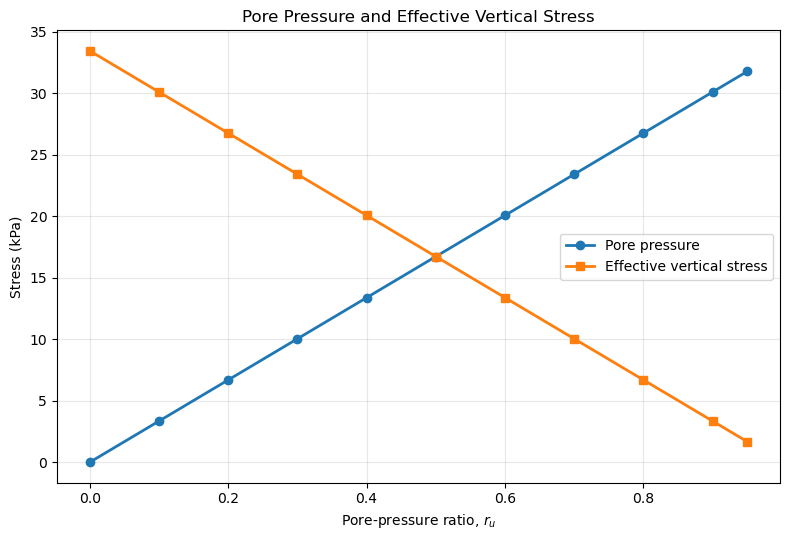

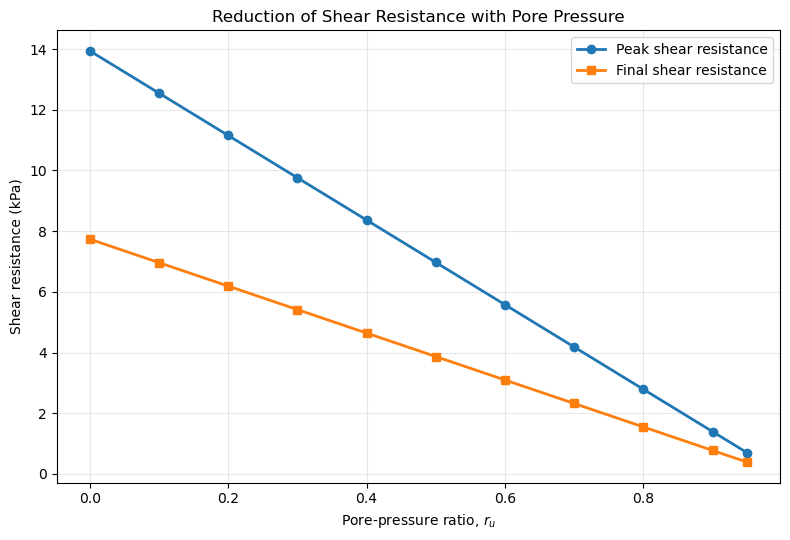

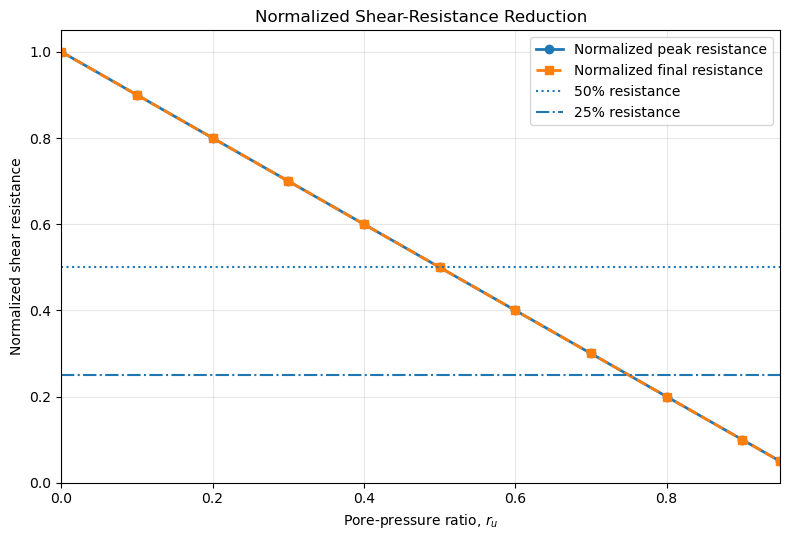

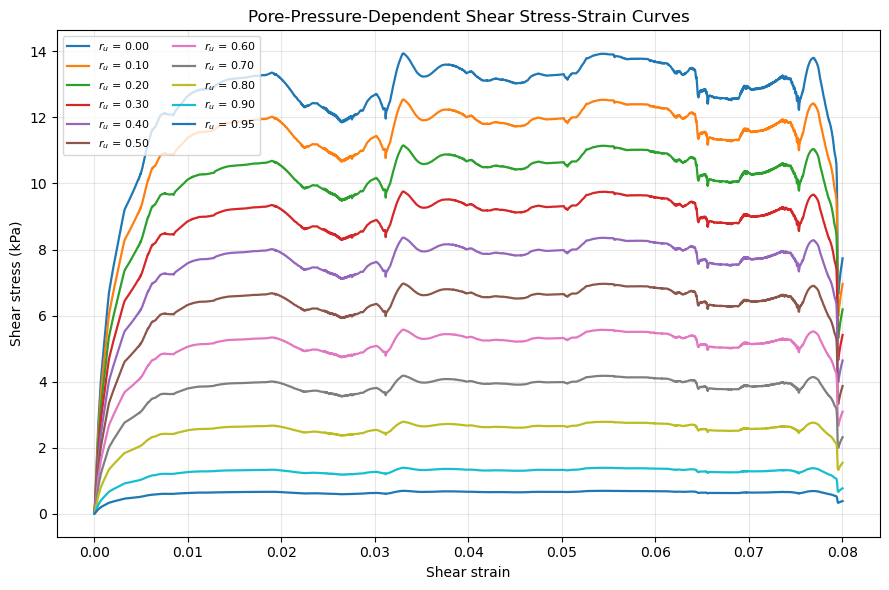

MAIN PORE-PRESSURE FIGURES SAVED
Saved: results\pore_pressure\figures\01_effective_stress_vs_pore_pressure_ratio.png
Saved: results\pore_pressure\figures\02_shear_resistance_vs_pore_pressure_ratio.png
Saved: results\pore_pressure\figures\03_normalized_shear_resistance.png
Saved: results\pore_pressure\figures\04_scaled_shear_stress_strain_curves.png

CELL 8 PASSED
Four main pore-pressure sensitivity plots were generated and saved successfully.


In [7]:
# ============================================================
# NOTEBOOK 04: PORE-PRESSURE SENSITIVITY
# CELL 8: PLOT MAIN SENSITIVITY RESULTS
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Create output folder for figures
# ------------------------------------------------------------

pore_pressure_figure_directory = Path(
    "results/pore_pressure/figures"
)

pore_pressure_figure_directory.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 2. Plot pore pressure and effective vertical stress
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

ax.plot(
    pore_pressure_ratio,
    pore_pressure / 1000.0,
    marker="o",
    linewidth=2.0,
    label="Pore pressure",
)

ax.plot(
    pore_pressure_ratio,
    effective_vertical_stress / 1000.0,
    marker="s",
    linewidth=2.0,
    label="Effective vertical stress",
)

ax.set_xlabel(
    "Pore-pressure ratio, $r_u$"
)

ax.set_ylabel(
    "Stress (kPa)"
)

ax.set_title(
    "Pore Pressure and Effective Vertical Stress"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

fig.tight_layout()

figure_1_path = (
    pore_pressure_figure_directory
    / "01_effective_stress_vs_pore_pressure_ratio.png"
)

fig.savefig(
    figure_1_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 3. Plot peak and final shear resistance
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

ax.plot(
    pore_pressure_ratio,
    peak_shear_resistance / 1000.0,
    marker="o",
    linewidth=2.0,
    label="Peak shear resistance",
)

ax.plot(
    pore_pressure_ratio,
    final_shear_resistance / 1000.0,
    marker="s",
    linewidth=2.0,
    label="Final shear resistance",
)

ax.set_xlabel(
    "Pore-pressure ratio, $r_u$"
)

ax.set_ylabel(
    "Shear resistance (kPa)"
)

ax.set_title(
    "Reduction of Shear Resistance with Pore Pressure"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

fig.tight_layout()

figure_2_path = (
    pore_pressure_figure_directory
    / "02_shear_resistance_vs_pore_pressure_ratio.png"
)

fig.savefig(
    figure_2_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 4. Plot normalized shear resistance
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

ax.plot(
    pore_pressure_ratio,
    normalized_peak_resistance,
    marker="o",
    linewidth=2.0,
    label="Normalized peak resistance",
)

ax.plot(
    pore_pressure_ratio,
    normalized_final_resistance,
    marker="s",
    linewidth=2.0,
    linestyle="--",
    label="Normalized final resistance",
)

ax.axhline(
    0.50,
    linewidth=1.5,
    linestyle=":",
    label="50% resistance",
)

ax.axhline(
    0.25,
    linewidth=1.5,
    linestyle="-.",
    label="25% resistance",
)

ax.set_xlabel(
    "Pore-pressure ratio, $r_u$"
)

ax.set_ylabel(
    "Normalized shear resistance"
)

ax.set_title(
    "Normalized Shear-Resistance Reduction"
)

ax.set_xlim(
    pore_pressure_ratio.min(),
    pore_pressure_ratio.max(),
)

ax.set_ylim(
    0.0,
    1.05,
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

fig.tight_layout()

figure_3_path = (
    pore_pressure_figure_directory
    / "03_normalized_shear_resistance.png"
)

fig.savefig(
    figure_3_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 5. Plot scaled shear stress-strain curves
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for case_index in range(
    number_of_pore_pressure_cases
):

    ax.plot(
        reference_shear_strain_history,
        scaled_shear_stress_histories[
            case_index,
            :
        ] / 1000.0,
        linewidth=1.6,
        label=(
            f"$r_u$ = "
            f"{pore_pressure_ratio[case_index]:.2f}"
        ),
    )

ax.set_xlabel(
    "Shear strain"
)

ax.set_ylabel(
    "Shear stress (kPa)"
)

ax.set_title(
    "Pore-Pressure-Dependent Shear Stress-Strain Curves"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    ncol=2,
    fontsize=8,
)

fig.tight_layout()

figure_4_path = (
    pore_pressure_figure_directory
    / "04_scaled_shear_stress_strain_curves.png"
)

fig.savefig(
    figure_4_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 6. Validate saved figures
# ------------------------------------------------------------

saved_figure_paths = [
    figure_1_path,
    figure_2_path,
    figure_3_path,
    figure_4_path,
]

missing_saved_figures = [
    figure_path
    for figure_path in saved_figure_paths
    if not figure_path.exists()
]

if missing_saved_figures:
    raise FileNotFoundError(
        "The following figures were not saved:\n"
        + "\n".join(
            f"  - {figure_path}"
            for figure_path in missing_saved_figures
        )
    )


# ------------------------------------------------------------
# 7. Print summary
# ------------------------------------------------------------

print("MAIN PORE-PRESSURE FIGURES SAVED")
print("=" * 75)

for figure_path in saved_figure_paths:
    print(f"Saved: {figure_path}")

print("\nCELL 8 PASSED")
print(
    "Four main pore-pressure sensitivity plots were "
    "generated and saved successfully."
)


In [8]:
# ============================================================
# NOTEBOOK 04: PORE-PRESSURE SENSITIVITY
# CELL 9: SAVE SENSITIVITY RESULTS
# ============================================================


# ------------------------------------------------------------
# 1. Create the output directory
# ------------------------------------------------------------

pore_pressure_output_directory = Path(
    "results/pore_pressure"
)

pore_pressure_output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

pore_pressure_results_path = (
    pore_pressure_output_directory
    / "pore_pressure_sensitivity_results.npz"
)


# ------------------------------------------------------------
# 2. Save the complete sensitivity dataset
# ------------------------------------------------------------

np.savez_compressed(
    pore_pressure_results_path,

    # Reference state
    reference_total_vertical_stress=(
        reference_total_vertical_stress
    ),
    reference_final_vertical_stress=(
        reference_final_vertical_stress
    ),
    reference_peak_shear_stress=(
        reference_peak_shear_stress
    ),
    reference_final_shear_stress=(
        reference_final_shear_stress
    ),
    reference_peak_shear_strain=(
        reference_peak_shear_strain
    ),
    reference_final_shear_strain=(
        reference_final_shear_strain
    ),
    reference_peak_stress_ratio=(
        reference_peak_stress_ratio
    ),
    reference_final_stress_ratio=(
        reference_final_stress_ratio
    ),

    # Strength parameters
    effective_cohesion=effective_cohesion,
    peak_friction_coefficient=(
        peak_friction_coefficient
    ),
    final_friction_coefficient=(
        final_friction_coefficient
    ),
    peak_friction_angle_deg=(
        peak_friction_angle_deg
    ),
    final_friction_angle_deg=(
        final_friction_angle_deg
    ),

    # Pore-pressure cases
    pore_pressure_ratio=pore_pressure_ratio,
    pore_pressure=pore_pressure,
    total_vertical_stress=total_vertical_stress,
    effective_vertical_stress=(
        effective_vertical_stress
    ),
    effective_stress_ratio=(
        effective_stress_ratio
    ),
    stress_reduction_percent=(
        stress_reduction_percent
    ),

    # Strength sensitivity
    peak_shear_resistance=(
        peak_shear_resistance
    ),
    final_shear_resistance=(
        final_shear_resistance
    ),
    normalized_peak_resistance=(
        normalized_peak_resistance
    ),
    normalized_final_resistance=(
        normalized_final_resistance
    ),
    peak_resistance_reduction_percent=(
        peak_resistance_reduction_percent
    ),
    final_resistance_reduction_percent=(
        final_resistance_reduction_percent
    ),

    # Reference shear history
    reference_shear_strain_history=(
        reference_shear_strain_history
    ),
    reference_shear_stress_history=(
        reference_shear_stress_history
    ),
    reference_vertical_stress_history=(
        reference_vertical_stress_history
    ),
    reference_stress_ratio_history=(
        reference_stress_ratio_history
    ),

    # Scaled curves
    scaled_shear_stress_histories=(
        scaled_shear_stress_histories
    ),
    scaled_stress_ratio_histories=(
        scaled_stress_ratio_histories
    ),
    curve_peak_shear_stress=(
        curve_peak_shear_stress
    ),
    curve_peak_shear_strain=(
        curve_peak_shear_strain
    ),
    curve_final_shear_stress=(
        curve_final_shear_stress
    ),
    curve_final_shear_strain=(
        curve_final_shear_strain
    ),
    curve_peak_stress_ratio=(
        curve_peak_stress_ratio
    ),
    curve_final_stress_ratio=(
        curve_final_stress_ratio
    ),

    # Threshold cases
    peak_half_case=peak_half_case,
    peak_quarter_case=peak_quarter_case,
    final_half_case=final_half_case,

    # Metadata
    number_of_pore_pressure_cases=(
        number_of_pore_pressure_cases
    ),
    number_of_shear_states=(
        number_of_shear_states
    ),
    notebook_03_run_accepted=(
        notebook_03_run_accepted
    ),
)


# ------------------------------------------------------------
# 3. Confirm that the file was created
# ------------------------------------------------------------

if not pore_pressure_results_path.exists():
    raise FileNotFoundError(
        "The pore-pressure sensitivity results file "
        "was not created."
    )


# ------------------------------------------------------------
# 4. Reload the saved file for validation
# ------------------------------------------------------------

with np.load(
    pore_pressure_results_path,
    allow_pickle=False,
) as saved_file:

    saved_results = {
        key: saved_file[key].copy()
        for key in saved_file.files
    }


# ------------------------------------------------------------
# 5. Validate essential saved variables
# ------------------------------------------------------------

required_saved_keys = [
    "pore_pressure_ratio",
    "pore_pressure",
    "effective_vertical_stress",
    "peak_shear_resistance",
    "final_shear_resistance",
    "scaled_shear_stress_histories",
    "reference_shear_strain_history",
    "reference_peak_shear_stress",
    "reference_final_shear_stress",
]

missing_saved_keys = [
    key
    for key in required_saved_keys
    if key not in saved_results
]

if missing_saved_keys:
    raise KeyError(
        "The following variables are missing from "
        "the saved sensitivity file:\n"
        + "\n".join(
            f"  - {key}"
            for key in missing_saved_keys
        )
    )


# ------------------------------------------------------------
# 6. Check saved values against current values
# ------------------------------------------------------------

validation_pairs = {
    "pore-pressure ratios": (
        saved_results["pore_pressure_ratio"],
        pore_pressure_ratio,
    ),
    "pore pressure": (
        saved_results["pore_pressure"],
        pore_pressure,
    ),
    "effective vertical stress": (
        saved_results["effective_vertical_stress"],
        effective_vertical_stress,
    ),
    "peak shear resistance": (
        saved_results["peak_shear_resistance"],
        peak_shear_resistance,
    ),
    "final shear resistance": (
        saved_results["final_shear_resistance"],
        final_shear_resistance,
    ),
    "scaled shear histories": (
        saved_results["scaled_shear_stress_histories"],
        scaled_shear_stress_histories,
    ),
}

for quantity_name, (
    saved_values,
    current_values,
) in validation_pairs.items():

    if not np.allclose(
        saved_values,
        current_values,
        rtol=1.0e-12,
        atol=1.0e-12,
    ):
        raise ValueError(
            f"The saved {quantity_name} do not match "
            "the current calculated values."
        )


# ------------------------------------------------------------
# 7. Print save summary
# ------------------------------------------------------------

file_size_kb = (
    pore_pressure_results_path.stat().st_size
    / 1024.0
)

print("PORE-PRESSURE SENSITIVITY RESULTS SAVED")
print("=" * 78)
print(
    f"Output file                    : "
    f"{pore_pressure_results_path.resolve()}"
)
print(
    f"Number of stored variables     : "
    f"{len(saved_results)}"
)
print(
    f"Number of pressure cases       : "
    f"{number_of_pore_pressure_cases}"
)
print(
    f"Number of shear states         : "
    f"{number_of_shear_states}"
)
print(
    f"Scaled history array shape     : "
    f"{scaled_shear_stress_histories.shape}"
)
print(
    f"Compressed file size           : "
    f"{file_size_kb:.2f} kB"
)

print("\nREFERENCE RECOVERY CHECK")
print("=" * 78)
print(
    f"Peak resistance at r_u = 0     : "
    f"{saved_results['peak_shear_resistance'][0] / 1000.0:.4f} kPa"
)
print(
    f"Final resistance at r_u = 0    : "
    f"{saved_results['final_shear_resistance'][0] / 1000.0:.4f} kPa"
)
print(
    f"Peak resistance at r_u = 0.95  : "
    f"{saved_results['peak_shear_resistance'][-1] / 1000.0:.4f} kPa"
)
print(
    f"Final resistance at r_u = 0.95 : "
    f"{saved_results['final_shear_resistance'][-1] / 1000.0:.4f} kPa"
)

print("\nCELL 9 PASSED")
print(
    "The pore-pressure sensitivity dataset was saved "
    "and successfully reloaded."
)

PORE-PRESSURE SENSITIVITY RESULTS SAVED
Output file                    : C:\Users\duaas\dike_fem_dem_project\results\pore_pressure\pore_pressure_sensitivity_results.npz
Number of stored variables     : 43
Number of pressure cases       : 11
Number of shear states         : 3417
Scaled history array shape     : (11, 3417)
Compressed file size           : 444.10 kB

REFERENCE RECOVERY CHECK
Peak resistance at r_u = 0     : 13.9385 kPa
Final resistance at r_u = 0    : 7.7342 kPa
Peak resistance at r_u = 0.95  : 0.6969 kPa
Final resistance at r_u = 0.95 : 0.3867 kPa

CELL 9 PASSED
The pore-pressure sensitivity dataset was saved and successfully reloaded.


In [9]:
# ============================================================
# NOTEBOOK 04: PORE-PRESSURE SENSITIVITY
# CELL 10: FINAL VALIDATION AND ACCEPTANCE CHECK
# ============================================================


# ------------------------------------------------------------
# 1. Define acceptance checks
# ------------------------------------------------------------

acceptance_checks = {}


acceptance_checks[
    "Notebook 03 reference run accepted"
] = bool(
    notebook_03_run_accepted
)


acceptance_checks[
    "All pore-pressure ratios are valid"
] = bool(
    np.all(pore_pressure_ratio >= 0.0)
    and np.all(pore_pressure_ratio < 1.0)
    and np.all(np.diff(pore_pressure_ratio) > 0.0)
)


acceptance_checks[
    "Effective stress decreases monotonically"
] = bool(
    np.all(
        np.diff(effective_vertical_stress)
        < 0.0
    )
)


acceptance_checks[
    "Effective stresses remain positive"
] = bool(
    np.all(effective_vertical_stress > 0.0)
)


acceptance_checks[
    "Peak resistance decreases monotonically"
] = bool(
    np.all(
        np.diff(peak_shear_resistance)
        < 0.0
    )
)


acceptance_checks[
    "Final resistance decreases monotonically"
] = bool(
    np.all(
        np.diff(final_shear_resistance)
        < 0.0
    )
)


acceptance_checks[
    "Peak resistance remains above final resistance"
] = bool(
    np.all(
        peak_shear_resistance
        >= final_shear_resistance
    )
)


acceptance_checks[
    "Zero-pressure peak strength is recovered"
] = bool(
    np.isclose(
        peak_shear_resistance[0],
        reference_peak_shear_stress,
        rtol=1.0e-12,
        atol=1.0e-12,
    )
)


acceptance_checks[
    "Zero-pressure final strength is recovered"
] = bool(
    np.isclose(
        final_shear_resistance[0],
        reference_final_shear_stress,
        rtol=1.0e-12,
        atol=1.0e-12,
    )
)


acceptance_checks[
    "Scaled reference curve is recovered"
] = bool(
    np.allclose(
        scaled_shear_stress_histories[0],
        reference_shear_stress_history,
        rtol=1.0e-12,
        atol=1.0e-12,
    )
)


acceptance_checks[
    "All scaled histories are finite"
] = bool(
    np.all(
        np.isfinite(
            scaled_shear_stress_histories
        )
    )
)


acceptance_checks[
    "Saved sensitivity file exists"
] = bool(
    pore_pressure_results_path.exists()
)


acceptance_checks[
    "All four figures exist"
] = bool(
    all(
        figure_path.exists()
        for figure_path in saved_figure_paths
    )
)


# ------------------------------------------------------------
# 2. Evaluate overall acceptance
# ------------------------------------------------------------

number_of_checks = len(
    acceptance_checks
)

number_of_passed_checks = sum(
    acceptance_checks.values()
)

number_of_failed_checks = (
    number_of_checks
    - number_of_passed_checks
)

notebook_04_accepted = bool(
    number_of_failed_checks == 0
)


# ------------------------------------------------------------
# 3. Calculate final summary quantities
# ------------------------------------------------------------

maximum_tested_pore_pressure_ratio = float(
    pore_pressure_ratio[-1]
)

maximum_tested_pore_pressure = float(
    pore_pressure[-1]
)

minimum_effective_vertical_stress = float(
    effective_vertical_stress[-1]
)

minimum_peak_shear_resistance = float(
    peak_shear_resistance[-1]
)

minimum_final_shear_resistance = float(
    final_shear_resistance[-1]
)

maximum_strength_loss_percent = float(
    peak_resistance_reduction_percent[-1]
)


# ------------------------------------------------------------
# 4. Print acceptance checks
# ------------------------------------------------------------

print("NOTEBOOK 04 ACCEPTANCE CHECKS")
print("=" * 88)

for check_name, check_passed in acceptance_checks.items():

    check_status = (
        "PASS"
        if check_passed
        else "FAIL"
    )

    print(
        f"{check_status:<6} | {check_name}"
    )


# ------------------------------------------------------------
# 5. Print final diagnostics
# ------------------------------------------------------------

print("\nFINAL PORE-PRESSURE SENSITIVITY DIAGNOSTICS")
print("=" * 88)

print(
    f"Reference total vertical stress     : "
    f"{reference_total_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Reference peak shear resistance     : "
    f"{reference_peak_shear_stress / 1000.0:.4f} kPa"
)

print(
    f"Reference final shear resistance    : "
    f"{reference_final_shear_stress / 1000.0:.4f} kPa"
)

print(
    f"Peak friction angle estimate        : "
    f"{peak_friction_angle_deg:.3f} degrees"
)

print(
    f"Final friction angle estimate       : "
    f"{final_friction_angle_deg:.3f} degrees"
)

print(
    f"Maximum tested pore-pressure ratio  : "
    f"{maximum_tested_pore_pressure_ratio:.2f}"
)

print(
    f"Maximum tested pore pressure        : "
    f"{maximum_tested_pore_pressure / 1000.0:.4f} kPa"
)

print(
    f"Minimum effective vertical stress   : "
    f"{minimum_effective_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Minimum peak shear resistance       : "
    f"{minimum_peak_shear_resistance / 1000.0:.4f} kPa"
)

print(
    f"Minimum final shear resistance      : "
    f"{minimum_final_shear_resistance / 1000.0:.4f} kPa"
)

print(
    f"Maximum calculated strength loss    : "
    f"{maximum_strength_loss_percent:.1f}%"
)

print(
    f"Peak resistance reaches 50% at      : "
    f"r_u = {pore_pressure_ratio[peak_half_case]:.2f}"
)

print(
    f"Peak resistance reaches 25% at      : "
    f"r_u = {pore_pressure_ratio[peak_quarter_case]:.2f}"
)

print(
    f"Final resistance reaches 50% at     : "
    f"r_u = {pore_pressure_ratio[final_half_case]:.2f}"
)


# ------------------------------------------------------------
# 6. Print output files
# ------------------------------------------------------------

print("\nSAVED OUTPUTS")
print("=" * 88)

print(
    f"Sensitivity results file            : "
    f"{pore_pressure_results_path}"
)

for figure_index, figure_path in enumerate(
    saved_figure_paths,
    start=1,
):

    print(
        f"Figure {figure_index:<2d}                           : "
        f"{figure_path}"
    )


# ------------------------------------------------------------
# 7. Print final result
# ------------------------------------------------------------

print("\nACCEPTANCE SUMMARY")
print("=" * 88)

print(
    f"Checks passed                       : "
    f"{number_of_passed_checks}/{number_of_checks}"
)

print(
    f"Checks failed                       : "
    f"{number_of_failed_checks}"
)

print(
    f"Overall result                      : "
    f"{'NOTEBOOK 04 ACCEPTED' if notebook_04_accepted else 'NOTEBOOK 04 NOT ACCEPTED'}"
)


if not notebook_04_accepted:

    failed_checks = [
        check_name
        for check_name, check_passed
        in acceptance_checks.items()
        if not check_passed
    ]

    raise RuntimeError(
        "Notebook 04 failed the following acceptance checks:\n"
        + "\n".join(
            f"  - {check_name}"
            for check_name in failed_checks
        )
    )


print("\nCELL 10 PASSED")
print(
    "Notebook 04 is complete. The results are ready for "
    "Notebook 05: FEM-DEM Link."
)

NOTEBOOK 04 ACCEPTANCE CHECKS
PASS   | Notebook 03 reference run accepted
PASS   | All pore-pressure ratios are valid
PASS   | Effective stress decreases monotonically
PASS   | Effective stresses remain positive
PASS   | Peak resistance decreases monotonically
PASS   | Final resistance decreases monotonically
PASS   | Peak resistance remains above final resistance
PASS   | Zero-pressure peak strength is recovered
PASS   | Zero-pressure final strength is recovered
PASS   | Scaled reference curve is recovered
PASS   | All scaled histories are finite
PASS   | Saved sensitivity file exists
PASS   | All four figures exist

FINAL PORE-PRESSURE SENSITIVITY DIAGNOSTICS
Reference total vertical stress     : 33.4271 kPa
Reference peak shear resistance     : 13.9385 kPa
Reference final shear resistance    : 7.7342 kPa
Peak friction angle estimate        : 22.635 degrees
Final friction angle estimate       : 13.804 degrees
Maximum tested pore-pressure ratio  : 0.95
Maximum tested pore pressure    